
#Jesse Watts INFO 648 Final Project: West South Central Neighborhood Growth Prediction

This notebook is organized around the six CRISP-DM phases for the assigned **West South Central** Census division: **Arkansas, Louisiana, Oklahoma, and Texas**.


In [ ]:

# Core libraries used throughout the semester
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

RANDOM_SEED = 42
assigned_region = 'West South Central'
assigned_states = ['Arkansas', 'Louisiana', 'Oklahoma', 'Texas']
minimum_population = 100



## Phase 1: Business Understanding

**Target definition:**  
`grew = 1` when `growth_pct > 0`; otherwise `grew = 0`.

**Success criterion:**  
A useful model should beat the majority-class baseline and should beat chance-level AUC by at least 0.10. In this notebook, the working AUC success threshold is **0.60** because chance-level AUC is **0.50**.

**Primary evaluation metric:**  
AUC is treated as the primary metric because the funding agency needs a ranking of tracts/states by growth likelihood, not just a hard yes/no label. Accuracy, precision, and recall are still reported from the confusion matrix because the agency also needs to understand the practical consequences of false positives and false negatives.


## Phase 2: Data Understanding

In [ ]:
try:
    raw = pd.read_csv('student_tracts_raw (1).csv')
except:
    raw = pd.read_csv('student_tracts_raw.csv')

forecast_raw = pd.read_csv('forecast_tracts_2020.csv')
data_dictionary = pd.read_csv('data_dictionary.csv')
region_counts = pd.read_csv('region_tract_counts.csv')

print('Training file shape:', raw.shape)
print('Forecast file shape:', forecast_raw.shape)
display(region_counts[region_counts['division'] == assigned_region])
display(data_dictionary)


Training file shape: (73057, 49)
Forecast file shape: (73057, 48)


,division,states_in_division,num_states,tracts
4,West South Central,"Arkansas, Louisiana, Oklahoma, Texas",4,8145


,column,description
0,GISJOIN,identifier
1,STATE,identifier
2,STATEA,identifier
3,COUNTY,identifier
4,COUNTYA,identifier
5,TRACTA,identifier
6,pop_total_2010,2010 total population (exact count)
7,pop_total_2020,"2020 total population, interpolated to 2010 tr..."
8,housing_occupied_2010/2020,occupied housing units
9,housing_vacant_2010/2020,vacant housing units


In [ ]:

# Filter to only the assigned region.
wsc_raw = raw[raw['STATE'].isin(assigned_states)].copy()
wsc_forecast_raw = forecast_raw[forecast_raw['STATE'].isin(assigned_states)].copy()

print('Assigned states:', assigned_states)
print('Raw West South Central tracts:', len(wsc_raw))
print('Forecast West South Central tracts:', len(wsc_forecast_raw))

print('\nTraining tracts by state:')
display(wsc_raw['STATE'].value_counts())

print('\nForecast tracts by state:')
display(wsc_forecast_raw['STATE'].value_counts())


Assigned states: ['Arkansas', 'Louisiana', 'Oklahoma', 'Texas']
Raw West South Central tracts: 8145
Forecast West South Central tracts: 8145

Training tracts by state:


,count
STATE,
Texas,5265
Louisiana,1148
Oklahoma,1046
Arkansas,686



Forecast tracts by state:


,count
STATE,
Texas,5265
Louisiana,1148
Oklahoma,1046
Arkansas,686


In [ ]:

# Basic missingness / undefined-calculation checks before feature engineering.
missing_summary = pd.DataFrame({
    'check': [
        '2010 population equals 0',
        '2010 population below minimum cutoff',
        'land area equals 0',
        'settlement_type missing'
    ],
    'tracts': [
        (wsc_raw['pop_total_2010'] == 0).sum(),
        (wsc_raw['pop_total_2010'] < minimum_population).sum(),
        (wsc_raw['land_area_sqkm'] == 0).sum(),
        wsc_raw['settlement_type'].isna().sum()
    ]
})

display(missing_summary)


,check,tracts
0,2010 population equals 0,46
1,2010 population below minimum cutoff,74
2,land area equals 0,2
3,settlement_type missing,24



Rate normalization is required because raw tract counts mostly measure tract size. The model should learn tract composition, such as percent renter-occupied, percent vacant, age shares, and race/origin shares. The helper below builds the same feature names for 2010 training data and 2020 forecast data so the frozen model can be applied forward.


In [ ]:

def build_features(data, year, include_target=False, minimum_population=100):
    df = data[data['STATE'].isin(assigned_states)].copy()

    pop_col = 'pop_total_' + str(year)
    occupied_col = 'housing_occupied_' + str(year)
    vacant_col = 'housing_vacant_' + str(year)
    owner_col = 'housing_owner_occ_' + str(year)
    renter_col = 'housing_renter_occ_' + str(year)

    starting_rows = len(df)

    # Required cleaning: remove tracts where growth/rate/density calculations are undefined or unstable.
    df = df[(df[pop_col] >= minimum_population) &
            (df['land_area_sqkm'] > 0) &
            (df['settlement_type'].notna())].copy()

    model_df = df[['GISJOIN', 'STATE', 'COUNTY', pop_col,
                   'land_area_sqkm', 'density_perkm2', 'settlement_type']].copy()

    # Housing rates: vacancy uses all housing units; owner/renter shares use occupied units.
    housing_total = (df[occupied_col] + df[vacant_col]).replace(0, np.nan)
    occupied_total = df[occupied_col].replace(0, np.nan)

    model_df['pct_vacant'] = df[vacant_col] / housing_total * 100
    model_df['pct_owner_occ'] = df[owner_col] / occupied_total * 100
    model_df['pct_renter_occ'] = df[renter_col] / occupied_total * 100

    # Age and race/origin rates: each tract divided by its own population.
    age_cols = [col for col in df.columns if col.startswith('age_') and col.endswith('_' + str(year))]
    race_cols = [col for col in df.columns if col.startswith('race_') and col.endswith('_' + str(year))]

    for col in age_cols:
        new_col = col.replace('_' + str(year), '_pct')
        model_df[new_col] = df[col] / df[pop_col] * 100

    for col in race_cols:
        new_col = col.replace('_' + str(year), '_pct')
        model_df[new_col] = df[col] / df[pop_col] * 100

    # Training target: 2010-to-2020 population growth.
    if include_target:
        model_df['growth_pct'] = (df['pop_total_2020'] - df['pop_total_2010']) / df['pop_total_2010'] * 100
        model_df['grew'] = (model_df['growth_pct'] > 0).astype(int)

    before_dropna = len(model_df)
    model_df = model_df.dropna().copy()

    print('Feature build for', year)
    print('Starting rows:', starting_rows)
    print('Rows after population/land/settlement cleaning:', before_dropna)
    print('Rows dropped after rate calculations:', before_dropna - len(model_df))
    print('Final rows:', len(model_df))

    return model_df

model_data = build_features(raw, 2010, include_target=True, minimum_population=minimum_population)


Feature build for 2010
Starting rows: 8145
Rows after population/land/settlement cleaning: 8071
Rows dropped after rate calculations: 8
Final rows: 8063


In [ ]:

# Class balance and initial growth patterns.
print('Target class counts:')
display(model_data['grew'].value_counts())

print('Target class share:')
display(model_data['grew'].value_counts(normalize=True))

print('Average growth by settlement type:')
display(model_data.groupby('settlement_type')['growth_pct'].mean().sort_values(ascending=False))

print('Average growth by state:')
display(model_data.groupby('STATE')['growth_pct'].mean().sort_values(ascending=False))


Target class counts:


,count
grew,
1,4820
0,3243


Target class share:


,proportion
grew,
1,0.597792
0,0.402208


Average growth by settlement type:


,growth_pct
settlement_type,
suburban,19.483064
rural,7.896349
urban,4.737348


Average growth by state:


,growth_pct
STATE,
Texas,14.292663
Oklahoma,4.801305
Louisiana,2.925079
Arkansas,0.891551


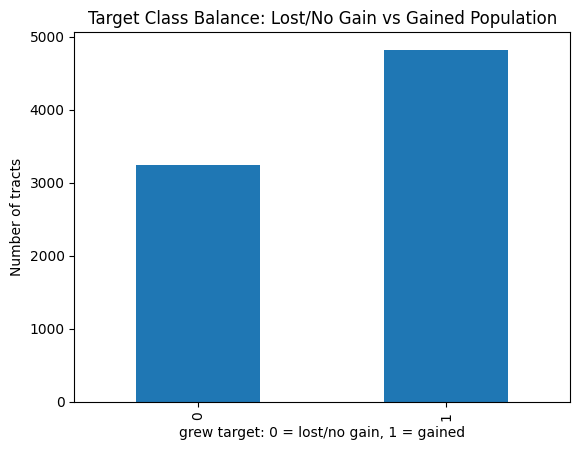

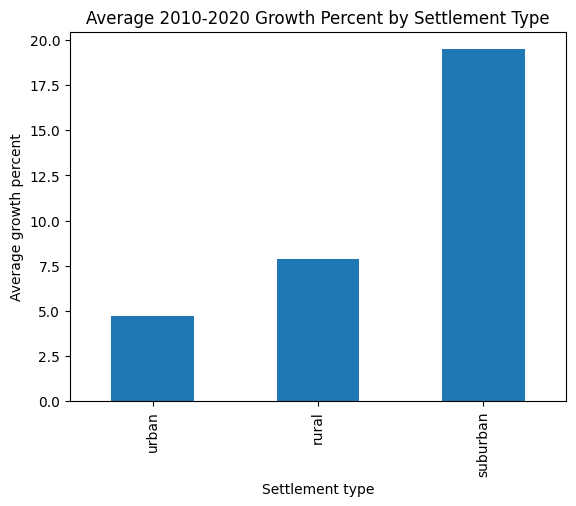

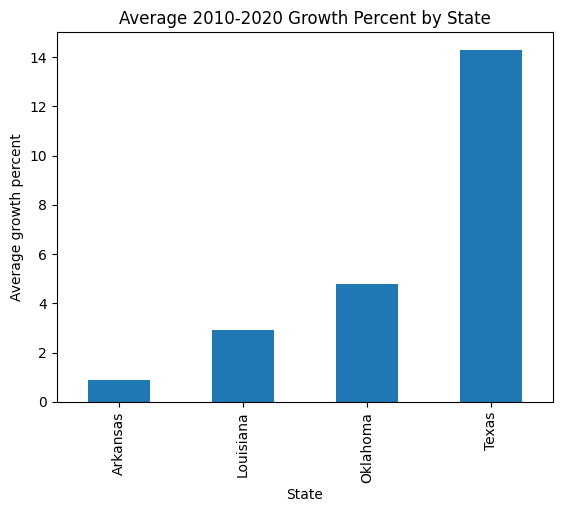

In [ ]:

# EDA visual 1: target class balance.
model_data['grew'].value_counts().sort_index().plot(kind='bar')
plt.title('Target Class Balance: Lost/No Gain vs Gained Population')
plt.xlabel('grew target: 0 = lost/no gain, 1 = gained')
plt.ylabel('Number of tracts')
plt.show()

# EDA visual 2: average growth by settlement type.
model_data.groupby('settlement_type')['growth_pct'].mean().sort_values().plot(kind='bar')
plt.title('Average 2010-2020 Growth Percent by Settlement Type')
plt.xlabel('Settlement type')
plt.ylabel('Average growth percent')
plt.show()

# EDA visual 3: average growth by state.
model_data.groupby('STATE')['growth_pct'].mean().sort_values().plot(kind='bar')
plt.title('Average 2010-2020 Growth Percent by State')
plt.xlabel('State')
plt.ylabel('Average growth percent')
plt.show()


## Phase 3: Data Preparation

In [ ]:

# Define features and target. Identifier columns and future population columns are not used as model inputs.
identifier_cols = ['GISJOIN', 'COUNTY', 'pop_total_2010', 'growth_pct', 'grew']
categorical_features = ['STATE', 'settlement_type']
numeric_features = [col for col in model_data.columns if col not in identifier_cols + categorical_features]

X = model_data[numeric_features + categorical_features].copy()
y = model_data['grew'].copy()

print('Number of numeric features:', len(numeric_features))
print('Categorical features:', categorical_features)
print('Target column: grew')
print('Check for accidental 2020 training inputs:', [col for col in X.columns if '2020' in col])

majority_baseline_accuracy = y.value_counts(normalize=True).max()
print('Majority-class baseline accuracy:', round(majority_baseline_accuracy, 3))
print('Chance-level AUC baseline: 0.500')


Number of numeric features: 39
Categorical features: ['STATE', 'settlement_type']
Target column: grew
Check for accidental 2020 training inputs: []
Majority-class baseline accuracy: 0.598
Chance-level AUC baseline: 0.500


In [ ]:

# Split tracts into train and test BEFORE fitting the scaler, k-means, or classifiers.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('\nTraining target balance:')
display(y_train.value_counts(normalize=True))
print('\nTest target balance:')
display(y_test.value_counts(normalize=True))


X_train shape: (6047, 41)
X_test shape: (2016, 41)

Training target balance:


,proportion
grew,
1,0.597817
0,0.402183



Test target balance:


,proportion
grew,
1,0.597718
0,0.402282



## Phase 4: Modeling

The modeling workflow has two parts:

1. Fit k-means on the **training set only** using numeric 2010 tract-rate features.
2. Add the train-fitted cluster label as a categorical feature, then train two classifiers.

The k-means scaler and k-means model are deliberately kept separate and frozen so the same scaler/clusters can be applied to the test set and later to the 2020 forecast file.


clusters 1 inertia 3247.0058392757874
clusters 2 inertia 2335.853141411343
clusters 3 inertia 1976.2319537192593
clusters 4 inertia 1735.4724512357168
clusters 5 inertia 1596.2942240319096
clusters 6 inertia 1501.1685964654653


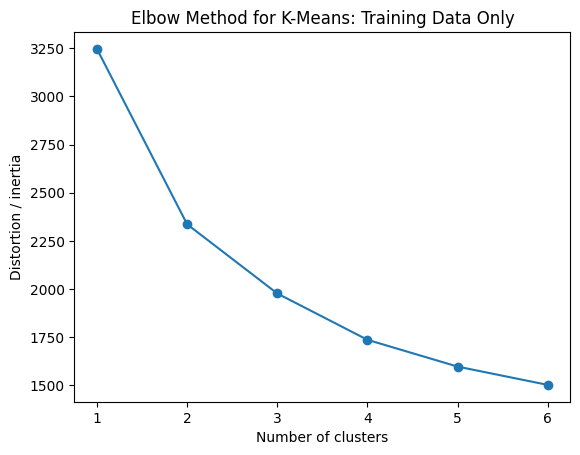

In [ ]:

# K-means elbow method using training data only.
k_scaler = MinMaxScaler()
X_train_scaled_for_kmeans = k_scaler.fit_transform(X_train[numeric_features])

distortions = []
cluster_range = range(1, 7)

for i in cluster_range:
    kmeans_check = KMeans(n_clusters=i, random_state=RANDOM_SEED, n_init=2, max_iter=100)
    kmeans_check.fit(X_train_scaled_for_kmeans)
    distortions.append(kmeans_check.inertia_)
    print('clusters', i, 'inertia', kmeans_check.inertia_)

plt.plot(list(cluster_range), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion / inertia')
plt.title('Elbow Method for K-Means: Training Data Only')
plt.show()


In [ ]:

chosen_k = 4

kmeans_model = KMeans(n_clusters=chosen_k, random_state=RANDOM_SEED, n_init=5, max_iter=100)
kmeans_model.fit(X_train_scaled_for_kmeans)

X_train_clustered = X_train.copy()
X_test_clustered = X_test.copy()

X_train_clustered['Cluster'] = kmeans_model.labels_
X_test_clustered['Cluster'] = kmeans_model.predict(k_scaler.transform(X_test[numeric_features]))

print('Training cluster balance:')
display(X_train_clustered['Cluster'].value_counts().sort_index())

print('Test cluster balance:')
display(X_test_clustered['Cluster'].value_counts().sort_index())


Training cluster balance:


,count
Cluster,
0,1423
1,884
2,602
3,3138


Test cluster balance:


,count
Cluster,
0,495
1,307
2,204
3,1010


In [ ]:

# Interpret each cluster by looking at average feature values in the training set.
cluster_profile = X_train_clustered[numeric_features + ['Cluster']].groupby('Cluster').mean()

# Select a smaller set of readable profile columns for interpretation.
profile_columns = [
    'density_perkm2',
    'land_area_sqkm',
    'pct_vacant',
    'pct_owner_occ',
    'pct_renter_occ',
    'age_under5_pct',
    'age_25to29_pct',
    'age_65to69_pct',
    'race_nhwhite_pct',
    'race_nhblack_pct',
    'race_hispwhite_pct'
]

available_profile_columns = [col for col in profile_columns if col in cluster_profile.columns]
display(cluster_profile[available_profile_columns].round(2))


,density_perkm2,land_area_sqkm,pct_vacant,pct_owner_occ,pct_renter_occ,age_under5_pct,age_25to29_pct,age_65to69_pct,race_nhwhite_pct,race_nhblack_pct,race_hispwhite_pct
Cluster,,,,,,,,,,,
0,1502.01,97.09,9.88,61.78,38.22,8.98,7.49,2.90,20.39,9.01,46.12
1,1735.73,9.18,12.42,30.60,69.40,7.12,12.15,2.45,50.83,16.31,12.65
2,1113.19,28.52,15.94,53.34,46.66,7.91,7.10,3.66,17.44,69.38,4.36
3,527.57,213.12,11.20,76.89,23.11,6.39,5.91,4.70,74.63,7.26,6.88


In [ ]:

# Preprocessors for the ablation.
# With-cluster model includes STATE, settlement_type, and Cluster as categorical features.
# Without-cluster model removes only the Cluster feature.
categorical_with_cluster = categorical_features + ['Cluster']

# Use small helper functions so each Pipeline gets a fresh preprocessor object.
def make_preprocess_with_cluster():
    return ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_with_cluster)
        ]
    )

def make_preprocess_without_cluster():
    return ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ]
    )


In [ ]:

# Simple tuning using a validation split from the training data only.
# This avoids using the test set to choose hyperparameters.
X_model_train, X_valid, y_model_train, y_valid = train_test_split(
    X_train_clustered, y_train,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y_train
)

def tune_decision_tree():
    rows = []
    best_auc = -1
    best_params = None

    for depth in [4, 8, 12]:
        for leaf in [10, 25]:
            model = Pipeline([
                ('preprocess', make_preprocess_with_cluster()),
                ('clf', DecisionTreeClassifier(max_depth=depth,
                                               min_samples_leaf=leaf,
                                               random_state=RANDOM_SEED))
            ])
            model.fit(X_model_train, y_model_train)
            validation_auc = roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])
            rows.append({'max_depth': depth,
                         'min_samples_leaf': leaf,
                         'validation_auc': validation_auc})

            if validation_auc > best_auc:
                best_auc = validation_auc
                best_params = {'max_depth': depth, 'min_samples_leaf': leaf}

    return pd.DataFrame(rows).sort_values('validation_auc', ascending=False), best_params

def tune_random_forest():
    rows = []
    best_auc = -1
    best_params = None

    for depth in [8, 12]:
        for leaf in [10]:
            model = Pipeline([
                ('preprocess', make_preprocess_with_cluster()),
                ('clf', RandomForestClassifier(n_estimators=30,
                                               max_depth=depth,
                                               min_samples_leaf=leaf,
                                               random_state=RANDOM_SEED))
            ])
            model.fit(X_model_train, y_model_train)
            validation_auc = roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])
            rows.append({'n_estimators': 30,
                         'max_depth': depth,
                         'min_samples_leaf': leaf,
                         'validation_auc': validation_auc})

            if validation_auc > best_auc:
                best_auc = validation_auc
                best_params = {'n_estimators': 30, 'max_depth': depth, 'min_samples_leaf': leaf}

    return pd.DataFrame(rows).sort_values('validation_auc', ascending=False), best_params

dt_tuning, dt_best_params = tune_decision_tree()
rf_tuning, rf_best_params = tune_random_forest()

print('Decision Tree tuning results:')
display(dt_tuning)
print('Chosen Decision Tree params:', dt_best_params)

print('\nRandom Forest tuning results:')
display(rf_tuning)
print('Chosen Random Forest params:', rf_best_params)


Decision Tree tuning results:


,max_depth,min_samples_leaf,validation_auc
3,8,25,0.747651
5,12,25,0.747580
1,4,25,0.733565
2,8,10,0.733298
0,4,10,0.731510
4,12,10,0.723251


Chosen Decision Tree params: {'max_depth': 8, 'min_samples_leaf': 25}

Random Forest tuning results:


,n_estimators,max_depth,min_samples_leaf,validation_auc
1,30,12,10,0.830645
0,30,8,10,0.818832


Chosen Random Forest params: {'n_estimators': 30, 'max_depth': 12, 'min_samples_leaf': 10}


In [ ]:

# Train final models with the selected hyperparameters.
dt_model = Pipeline([
    ('preprocess', make_preprocess_with_cluster()),
    ('clf', DecisionTreeClassifier(max_depth=dt_best_params['max_depth'],
                                   min_samples_leaf=dt_best_params['min_samples_leaf'],
                                   random_state=RANDOM_SEED))
])

rf_model = Pipeline([
    ('preprocess', make_preprocess_with_cluster()),
    ('clf', RandomForestClassifier(n_estimators=rf_best_params['n_estimators'],
                                   max_depth=rf_best_params['max_depth'],
                                   min_samples_leaf=rf_best_params['min_samples_leaf'],
                                   random_state=RANDOM_SEED))
])

# Ablation versions: same model settings, but no Cluster feature.
dt_model_no_cluster = Pipeline([
    ('preprocess', make_preprocess_without_cluster()),
    ('clf', DecisionTreeClassifier(max_depth=dt_best_params['max_depth'],
                                   min_samples_leaf=dt_best_params['min_samples_leaf'],
                                   random_state=RANDOM_SEED))
])

rf_model_no_cluster = Pipeline([
    ('preprocess', make_preprocess_without_cluster()),
    ('clf', RandomForestClassifier(n_estimators=rf_best_params['n_estimators'],
                                   max_depth=rf_best_params['max_depth'],
                                   min_samples_leaf=rf_best_params['min_samples_leaf'],
                                   random_state=RANDOM_SEED))
])

dt_model.fit(X_train_clustered, y_train)
print('Decision Tree with cluster trained.')
rf_model.fit(X_train_clustered, y_train)
print('Random Forest with cluster trained.')
dt_model_no_cluster.fit(X_train, y_train)
print('Decision Tree without cluster trained.')
rf_model_no_cluster.fit(X_train, y_train)
print('Random Forest without cluster trained.')

print('All final models are trained.')


Decision Tree with cluster trained.
Random Forest with cluster trained.
Decision Tree without cluster trained.
Random Forest without cluster trained.
All final models are trained.


## Phase 5: Evaluation

In [ ]:

def evaluate_model(model_name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]
    cm = confusion_matrix(y_test_data, y_pred)

    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / cm.sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    auc = roc_auc_score(y_test_data, y_prob)

    print('\n' + model_name)
    print('Confusion matrix:')
    print(cm)
    print(classification_report(y_test_data, y_pred, digits=3))
    print('Accuracy from matrix:', round(accuracy, 3))
    print('Precision from matrix:', round(precision, 3))
    print('Recall from matrix:', round(recall, 3))
    print('AUC:', round(auc, 3))

    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'auc': auc
    }

results = []
results.append(evaluate_model('Decision Tree with Cluster', dt_model, X_test_clustered, y_test))
results.append(evaluate_model('Random Forest with Cluster', rf_model, X_test_clustered, y_test))
results.append(evaluate_model('Decision Tree without Cluster', dt_model_no_cluster, X_test, y_test))
results.append(evaluate_model('Random Forest without Cluster', rf_model_no_cluster, X_test, y_test))

evaluation_table = pd.DataFrame(results).sort_values('auc', ascending=False)
display(evaluation_table.round(3))



Decision Tree with Cluster
Confusion matrix:
[[462 349]
 [235 970]]
              precision    recall  f1-score   support

           0      0.663     0.570     0.613       811
           1      0.735     0.805     0.769      1205

    accuracy                          0.710      2016
   macro avg      0.699     0.687     0.691      2016
weighted avg      0.706     0.710     0.706      2016

Accuracy from matrix: 0.71
Precision from matrix: 0.735
Recall from matrix: 0.805
AUC: 0.772

Random Forest with Cluster
Confusion matrix:
[[ 510  301]
 [ 177 1028]]
              precision    recall  f1-score   support

           0      0.742     0.629     0.681       811
           1      0.774     0.853     0.811      1205

    accuracy                          0.763      2016
   macro avg      0.758     0.741     0.746      2016
weighted avg      0.761     0.763     0.759      2016

Accuracy from matrix: 0.763
Precision from matrix: 0.774
Recall from matrix: 0.853
AUC: 0.829

Decision Tree wi

,model,accuracy,precision,recall,auc
1,Random Forest with Cluster,0.763,0.774,0.853,0.829
3,Random Forest without Cluster,0.748,0.758,0.850,0.827
2,Decision Tree without Cluster,0.711,0.735,0.809,0.773
0,Decision Tree with Cluster,0.710,0.735,0.805,0.772


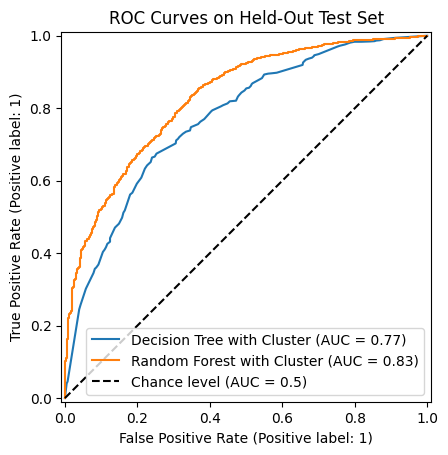

In [ ]:

# ROC curves for the two cluster-enabled models.
ax = plt.gca()
RocCurveDisplay.from_estimator(dt_model, X_test_clustered, y_test, ax=ax, name='Decision Tree with Cluster')
RocCurveDisplay.from_estimator(rf_model, X_test_clustered, y_test, ax=ax, name='Random Forest with Cluster', plot_chance_level=True)
plt.title('ROC Curves on Held-Out Test Set')
plt.show()


In [ ]:

# Ablation table: compare each classifier with and without the cluster feature.
ablation_table = evaluation_table[['model', 'auc', 'accuracy', 'precision', 'recall']].copy()
display(ablation_table.round(3))

simple_without = ablation_table[ablation_table['model'] == 'Decision Tree without Cluster']['auc'].iloc[0]
simple_with = ablation_table[ablation_table['model'] == 'Decision Tree with Cluster']['auc'].iloc[0]
ensemble_without = ablation_table[ablation_table['model'] == 'Random Forest without Cluster']['auc'].iloc[0]
ensemble_with = ablation_table[ablation_table['model'] == 'Random Forest with Cluster']['auc'].iloc[0]

print('Decision Tree cluster AUC lift:', round(simple_with - simple_without, 4))
print('Random Forest cluster AUC lift:', round(ensemble_with - ensemble_without, 4))


,model,auc,accuracy,precision,recall
1,Random Forest with Cluster,0.829,0.763,0.774,0.853
3,Random Forest without Cluster,0.827,0.748,0.758,0.850
2,Decision Tree without Cluster,0.773,0.711,0.735,0.809
0,Decision Tree with Cluster,0.772,0.710,0.735,0.805


Decision Tree cluster AUC lift: -0.001
Random Forest cluster AUC lift: 0.0025



**Metric interpretation:** AUC is the main metric because it evaluates how well the model ranks growth likelihood across tracts. For a funding allocation problem, a ranking is useful because the agency can prioritize states and tracts with the highest predicted growth risk/opportunity even if the exact binary cutoff changes.

**Leakage discussion:** The split was created before scaling, k-means, and classifier fitting. The scaler and k-means were fit only on the training set, then applied to the test and forecast sets. No 2020 demographic features are used as training inputs; 2020 population is used only to build the historical target. A remaining limitation is spatial leakage: nearby tracts are similar, so a random split can make performance look somewhat optimistic compared with a future state- or county-held-out test.


In [ ]:

# Select the best cluster-enabled model for the forecast step.
# The capstone forecast uses the frozen scaler, frozen k-means, and a cluster-enabled classifier.
dt_cluster_auc = evaluation_table[evaluation_table['model'] == 'Decision Tree with Cluster']['auc'].iloc[0]
rf_cluster_auc = evaluation_table[evaluation_table['model'] == 'Random Forest with Cluster']['auc'].iloc[0]

if rf_cluster_auc >= dt_cluster_auc:
    best_model_name = 'Random Forest with Cluster'
    best_model = rf_model
else:
    best_model_name = 'Decision Tree with Cluster'
    best_model = dt_model

print('Best cluster-enabled model selected for forecasting:', best_model_name)


Best cluster-enabled model selected for forecasting: Random Forest with Cluster


,feature,importance
30,race_nhapi_pct,0.073687
33,race_hispwhite_pct,0.066861
1,density_perkm2,0.063264
2,pct_vacant,0.062120
0,land_area_sqkm,0.053937
15,age_35to39_pct,0.048675
9,age_18to19_pct,0.037517
27,race_nhwhite_pct,0.035716
32,race_nhtwo_pct,0.029280
26,age_85plus_pct,0.028573


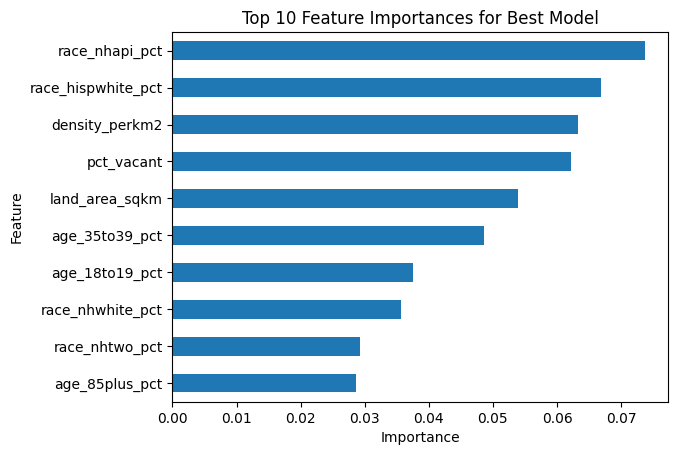

In [ ]:

# Feature importance for the best model.
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
importances = best_model.named_steps['clf'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Clean feature names for readability.
importance_df['feature'] = importance_df['feature'].str.replace('num__', '', regex=False)
importance_df['feature'] = importance_df['feature'].str.replace('cat__', '', regex=False)

top_importance = importance_df.head(10).copy()
display(top_importance)

top_importance.sort_values('importance').plot(kind='barh', x='feature', y='importance', legend=False)
plt.title('Top 10 Feature Importances for Best Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


## Phase 6: Deployment / 2020-to-2030 Forecast

In [ ]:

# Build the 2020 forecast features using the exact same feature names and per-tract rate logic.
forecast_data = build_features(forecast_raw, 2020, include_target=False, minimum_population=minimum_population)
forecast_features = forecast_data[numeric_features + categorical_features].copy()

# Apply the frozen 2010-training scaler and k-means to assign 2020 tracts to neighborhood types.
forecast_features['Cluster'] = kmeans_model.predict(k_scaler.transform(forecast_features[numeric_features]))
forecast_data['Cluster'] = forecast_features['Cluster']

# Use the same model feature order used in training.
model_feature_columns = numeric_features + categorical_with_cluster

# The frozen OneHotEncoder inside the Pipeline handles the column alignment.
forecast_processed = best_model.named_steps['preprocess'].transform(forecast_features[model_feature_columns])
if hasattr(forecast_processed, 'toarray'):
    forecast_processed_preview = forecast_processed[:5].toarray()
else:
    forecast_processed_preview = forecast_processed[:5]

aligned_columns = best_model.named_steps['preprocess'].get_feature_names_out()
print('Forecast rows:', len(forecast_features))
print('Number of aligned model columns:', len(aligned_columns))
display(pd.DataFrame(forecast_processed_preview, columns=aligned_columns).head())


Feature build for 2020
Starting rows: 8145
Rows after population/land/settlement cleaning: 8078
Rows dropped after rate calculations: 7
Final rows: 8071
Forecast rows: 8071
Number of aligned model columns: 50


,num__land_area_sqkm,num__density_perkm2,num__pct_vacant,num__pct_owner_occ,num__pct_renter_occ,num__age_under5_pct,num__age_5to9_pct,num__age_10to14_pct,num__age_15to17_pct,num__age_18to19_pct,...,cat__STATE_Louisiana,cat__STATE_Oklahoma,cat__STATE_Texas,cat__settlement_type_rural,cat__settlement_type_suburban,cat__settlement_type_urban,cat__Cluster_0,cat__Cluster_1,cat__Cluster_2,cat__Cluster_3
0,0.043107,0.000078,0.234830,0.854093,0.145907,0.156023,0.267270,0.359337,0.115703,0.018816,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.044830,0.000093,0.189617,0.806448,0.193552,0.174334,0.377807,0.266419,0.129219,0.020300,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.002560,0.003078,0.122485,0.657066,0.342934,0.280861,0.456539,0.458843,0.173584,0.029209,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.003782,0.001707,0.162722,0.456653,0.543347,0.284591,0.406666,0.450280,0.158857,0.022798,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.000865,0.012775,0.138741,0.600489,0.399511,0.306171,0.396394,0.466320,0.146367,0.026447,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


,STATE,tracts,predicted_growth_tracts,share_predicted_to_grow,avg_probability_growth
3,Texas,5216,3990,76.50,62.21
2,Oklahoma,1046,603,57.65,50.86
1,Louisiana,1125,560,49.78,47.74
0,Arkansas,684,330,48.25,47.53


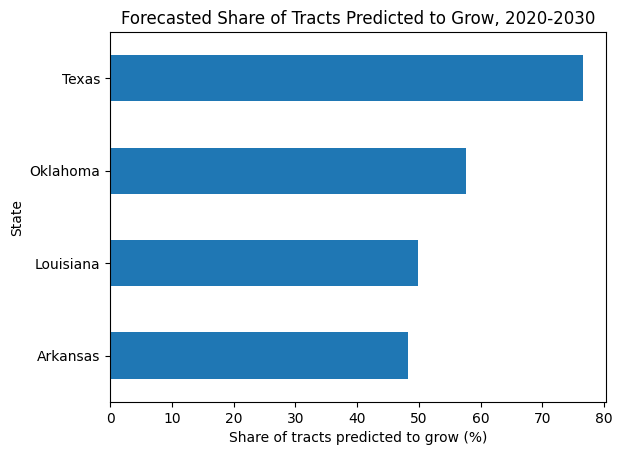

In [ ]:

# Predict 2020-to-2030 growth outcome.
forecast_data['predicted_grew_2020_2030'] = best_model.predict(forecast_features[model_feature_columns])
forecast_data['prob_growth_2030'] = best_model.predict_proba(forecast_features[model_feature_columns])[:, 1]

forecast_summary = forecast_data.groupby('STATE').agg(
    tracts=('GISJOIN', 'count'),
    predicted_growth_tracts=('predicted_grew_2020_2030', 'sum'),
    share_predicted_to_grow=('predicted_grew_2020_2030', 'mean'),
    avg_probability_growth=('prob_growth_2030', 'mean')
).reset_index().sort_values('share_predicted_to_grow', ascending=False)

forecast_summary['share_predicted_to_grow'] = forecast_summary['share_predicted_to_grow'] * 100
forecast_summary['avg_probability_growth'] = forecast_summary['avg_probability_growth'] * 100

display(forecast_summary.round(2))

forecast_summary.sort_values('share_predicted_to_grow').plot(
    kind='barh',
    x='STATE',
    y='share_predicted_to_grow',
    legend=False
)
plt.title('Forecasted Share of Tracts Predicted to Grow, 2020-2030')
plt.xlabel('Share of tracts predicted to grow (%)')
plt.ylabel('State')
plt.show()


In [ ]:

# Save forecast outputs for the GitHub repo / presentation.
forecast_summary.to_csv('west_south_central_forecast_summary.csv', index=False)
forecast_data[['GISJOIN', 'STATE', 'COUNTY', 'Cluster', 'predicted_grew_2020_2030', 'prob_growth_2030']].to_csv(
    'west_south_central_tract_forecast.csv',
    index=False
)

print('Saved west_south_central_forecast_summary.csv')
print('Saved west_south_central_tract_forecast.csv')


Saved west_south_central_forecast_summary.csv
Saved west_south_central_tract_forecast.csv
